<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/Nhan_dien_benh_phoi_bang_mo_hinh_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os

# 2. Định nghĩa đường dẫn (Hãy thay đổi tên folder cho đúng với Drive của bạn)
# Giả sử folder 'chest_xray' nằm ngay ngoài cùng của My Drive
base_dir = '/content/drive/MyDrive/CNN/chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# 3. Cấu hình ImageDataGenerator với validation_split
# Chúng ta sẽ thực hiện Augmentation (tăng cường dữ liệu) cho tập Train
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Chuẩn hóa pixel về [0, 1]
    validation_split=0.2,      # QUAN TRỌNG: Chia 20% dữ liệu để làm Validation
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Tập Test chỉ cần rescale, không cần split hay augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# 4. Tạo các bộ nạp dữ liệu (Generators)

# Bộ nạp cho tập TRAIN (80% của thư mục train)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training',         # Xác định đây là phần training (80%)
    seed=123                   # Giữ seed cố định để việc chia file không bị xáo trộn mỗi lần chạy
)

# Bộ nạp cho tập VALIDATION (20% còn lại của thư mục train)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',       # Xác định đây là phần validation (20%)
    seed=123
)

# Bộ nạp cho tập TEST (Giữ nguyên từ thư mục test)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Kiểm tra nhãn lớp
print("Nhãn của các lớp:", train_generator.class_indices)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Nhãn của các lớp: {'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
from tensorflow.keras import layers, models

# Khởi tạo mô hình tuần tự
model = models.Sequential([
    # Khối 1: Trích xuất các đặc trưng cơ bản (đường nét)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Khối 2: Trích xuất đặc trưng phức tạp hơn
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Khối 3:
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Chuyển đổi dữ liệu từ dạng ảnh sang dạng phẳng (vector)
    layers.Flatten(),

    # Lớp Dense (Fully Connected) để phân loại
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Chống học vẹt (overfitting)
    layers.Dense(1, activation='sigmoid') # 1 đầu ra: 0 (Normal) hoặc 1 (Pneumonia)
])


In [7]:
from tensorflow.keras import optimizers

# 1. Khai báo siêu tham số (Hyper-parameters)
LR = 0.001          # Tỷ lệ học (Learning Rate)
BATCH_SIZE = 32     # Số lượng mẫu dữ liệu trong một lần cập nhật trọng số
EPOCHS = 30         # Tổng số vòng lặp huấn luyện
OPTIMIZER = optimizers.Adam(learning_rate=LR)
LOSS_FUNCTION = 'binary_crossentropy'

# 2. Biên dịch mô hình (Compile)
model.compile(
    optimizer=OPTIMIZER,
    loss=LOSS_FUNCTION,
    metrics=['accuracy']
)

print("Đã cấu hình xong siêu tham số. Sẵn sàng huấn luyện!")

Đã cấu hình xong siêu tham số. Sẵn sàng huấn luyện!


In [9]:
# Huấn luyện
history = model.fit(
    train_generator,
    epochs=EPOCHS, # Sử dụng biến EPOCHS đã khai báo ở trên
    validation_data=validation_generator
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 776s 6s/step - accuracy: 0.8042 - loss: 0.4516 - val_accuracy: 0.8651 - val_loss: 0.3051
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 359s 3s/step - accuracy: 0.8894 - loss: 0.2586 - val_accuracy: 0.9340 - val_loss: 0.1702
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.8901 - loss: 0.2682 - val_accuracy: 0.9014 - val_loss: 0.2356
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 352s 3s/step - accuracy: 0.9042 - loss: 0.2256 - val_accuracy: 0.9359 - val_loss: 0.1606
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.9198 - loss: 0.2042 - val_accuracy: 0.9368 - val_loss: 0.1467
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 358s 3s/step - accuracy: 0.9190 - loss: 0.2024 - val_accuracy: 0.9435 - val_loss: 0.1506
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 357s 3s/step - accuracy: 0.9334 - loss: 0.1840 - val_accuracy: 0.9455 - val_loss: 0.1367
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.9372 - loss: 0.1643 - val_accu

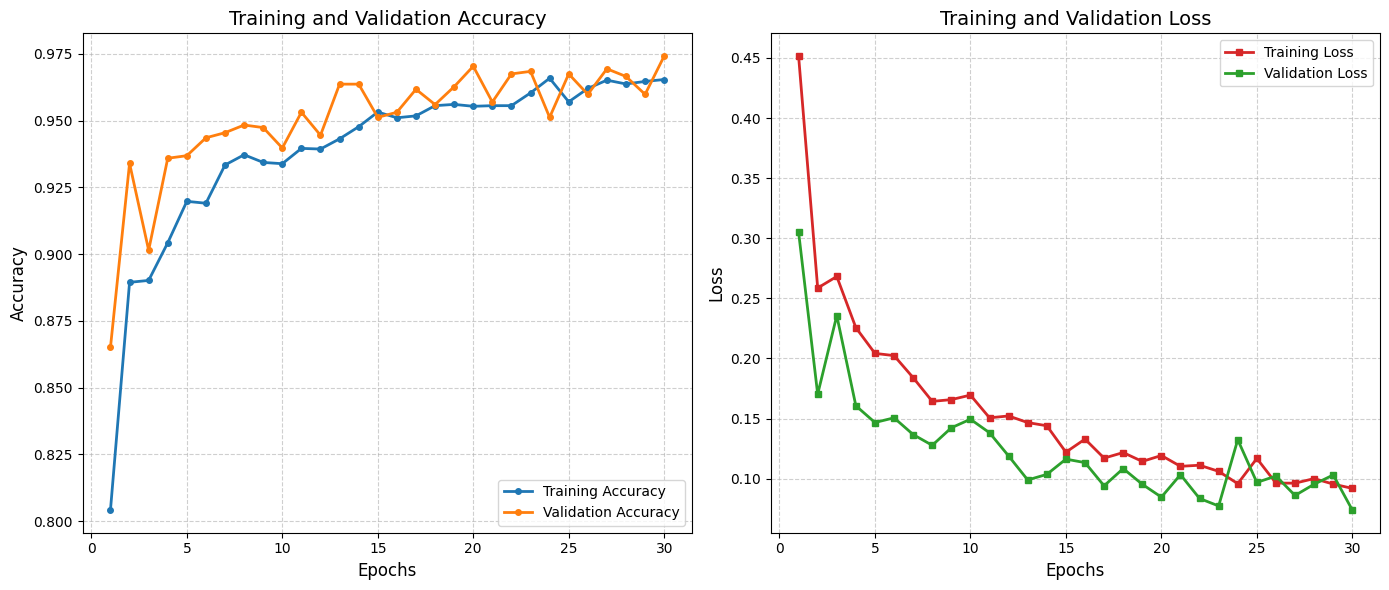

In [10]:
import matplotlib.pyplot as plt

# Trích xuất dữ liệu từ biến history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Khởi tạo khung hình
plt.figure(figsize=(14, 6))

# --- Biểu đồ Accuracy (Độ chính xác) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, marker='o', markersize=4)
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Biểu đồ Loss (Sai số) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2, marker='s', markersize=4)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2, marker='s', markersize=4)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('ket_qua_huan_luyen.png', dpi=300)
plt.show()

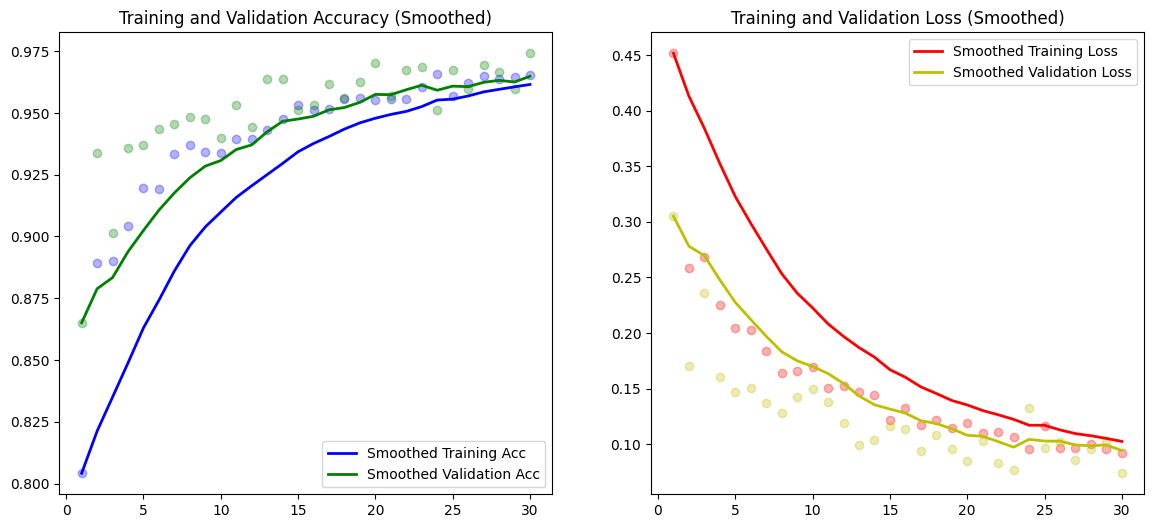

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# Lấy dữ liệu
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Vẽ biểu đồ
plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
# Vẽ đường gốc (mờ)
plt.plot(epochs, acc, 'bo', alpha=0.3)
plt.plot(epochs, val_acc, 'go', alpha=0.3)
# Vẽ đường đã làm mượt (đậm)
plt.plot(epochs, smooth_curve(acc), 'b', label='Smoothed Training Acc', linewidth=2)
plt.plot(epochs, smooth_curve(val_acc), 'g', label='Smoothed Validation Acc', linewidth=2)
plt.title('Training and Validation Accuracy (Smoothed)')
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
# Vẽ đường gốc (mờ)
plt.plot(epochs, loss, 'ro', alpha=0.3)
plt.plot(epochs, val_loss, 'yo', alpha=0.3)
# Vẽ đường đã làm mượt (đậm)
plt.plot(epochs, smooth_curve(loss), 'r', label='Smoothed Training Loss', linewidth=2)
plt.plot(epochs, smooth_curve(val_loss), 'y', label='Smoothed Validation Loss', linewidth=2)
plt.title('Training and Validation Loss (Smoothed)')
plt.legend()

plt.show()

Found 1045 images belonging to 2 classes.
Đang tiến hành dự đoán...
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


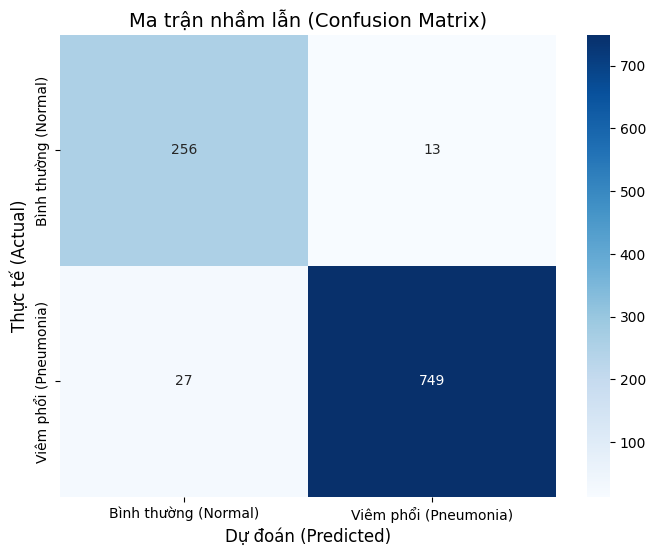


--- Báo cáo phân loại chi tiết ---
              precision    recall  f1-score   support

      Normal       0.90      0.95      0.93       269
   Pneumonia       0.98      0.97      0.97       776

    accuracy                           0.96      1045
   macro avg       0.94      0.96      0.95      1045
weighted avg       0.96      0.96      0.96      1045



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# BƯỚC 1: Tạo một generator riêng để kiểm tra (tắt shuffle để nhãn khớp với ảnh)
# Thay 'path_to_train_data' bằng biến chứa đường dẫn thư mục train của bạn
eval_generator = train_datagen.flow_from_directory(
    train_dir,                # Thư mục chứa dữ liệu
    target_size=(150, 150),   # Phải khớp với lúc train
    batch_size=32,
    class_mode='binary',
    subset='validation',      # Lấy đúng tập validation
    shuffle=False             # QUAN TRỌNG: Không xáo trộn để lấy đúng nhãn y_true
)

# BƯỚC 2: Dự đoán
print("Đang tiến hành dự đoán...")
y_pred_probs = model.predict(eval_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = eval_generator.classes

# BƯỚC 3: Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bình thường (Normal)', 'Viêm phổi (Pneumonia)'],
            yticklabels=['Bình thường (Normal)', 'Viêm phổi (Pneumonia)'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.show()

# BƯỚC 4: In báo cáo chi tiết Precision, Recall, F1-score
print("\n--- Báo cáo phân loại chi tiết ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

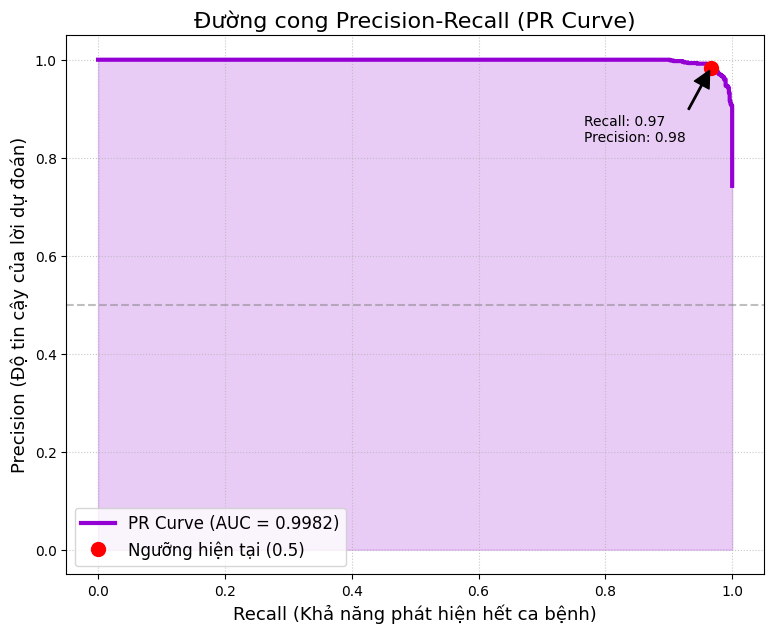

In [14]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Giả sử bạn đã có y_true và y_pred_probs từ bước dự đoán trước đó
# Tính toán các giá trị Precision và Recall ứng với các ngưỡng (thresholds) khác nhau
precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(9, 7))

# Vẽ đường cong PR
plt.plot(recall, precision, color='darkviolet', lw=3, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.fill_between(recall, precision, alpha=0.2, color='darkviolet')

# Đánh dấu điểm Threshold 0.5 (điểm mà bạn đang dùng cho Confusion Matrix)
# Tìm vị trí gần ngưỡng 0.5 nhất trong mảng thresholds
idx = (np.abs(thresholds - 0.5)).argmin()
plt.plot(recall[idx], precision[idx], 'ro', markersize=10, label=f'Ngưỡng hiện tại (0.5)')

# Trang trí biểu đồ
plt.title('Đường cong Precision-Recall (PR Curve)', fontsize=16)
plt.xlabel('Recall (Khả năng phát hiện hết ca bệnh)', fontsize=13)
plt.ylabel('Precision (Độ tin cậy của lời dự đoán)', fontsize=13)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5) # Đường tham chiếu
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Thêm chú thích cho điểm 0.5
plt.annotate(f'Recall: {recall[idx]:.2f}\nPrecision: {precision[idx]:.2f}',
             xy=(recall[idx], precision[idx]),
             xytext=(recall[idx]-0.2, precision[idx]-0.15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()